In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

BASE  = Path(r"E:\bluestock_mf_capstone")
PROC  = BASE / "data" / "processed"
CHARTS = BASE / "reports"

nav  = pd.read_csv(PROC / "clean_nav_history.csv")
fm   = pd.read_csv(PROC / "clean_fund_master.csv")
perf = pd.read_csv(PROC / "clean_scheme_performance.csv")
bench = pd.read_csv(PROC / "clean_benchmark_indices.csv")

nav["date"] = pd.to_datetime(nav["date"])
bench["date"] = pd.to_datetime(bench["date"])

print("All loaded successfully")
print("NAV shape:", nav.shape)
print("Benchmark shape:", bench.shape)
print("Benchmark columns:", bench.columns.tolist())

All loaded successfully
NAV shape: (46000, 4)
Benchmark shape: (8050, 3)
Benchmark columns: ['date', 'index_name', 'close_value']


In [2]:
print(bench["index_name"].unique())

['NIFTY50' 'CRISIL_LIQUID' 'NIFTY_MIDCAP150' 'CRISIL_GILT' 'NIFTY100'
 'NIFTY500' 'BSE_SMALLCAP']


## Step 1 — Compute Daily Returns for All Funds

In [5]:
# Sort by fund and date first
nav = nav.sort_values(["amfi_code", "date"]).reset_index(drop=True)

# Calculate daily return for each fund separately
# pct_change() does (today - yesterday) / yesterday
# groupby ensures we don't calculate return across different funds
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
    .pct_change()
)

# Remove first row of each fund (no previous day to compare)
nav_returns = nav.dropna(subset=["daily_return"])

print("Daily returns calculated")
print(f"Total rows: {len(nav_returns)}")
print(f"Sample returns:")
print(nav_returns[["amfi_code","date","nav","daily_return"]].head(5))

Daily returns calculated
Total rows: 45960
Sample returns:
   amfi_code       date       nav  daily_return
1     100016 2022-01-04  515.0971     -0.010306
2     100016 2022-01-05  521.7239      0.012865
3     100016 2022-01-06  515.7880     -0.011377
4     100016 2022-01-07  515.1639     -0.001210
5     100016 2022-01-10  510.7136     -0.008639


## Step 2 — Calculate CAGR for Every Fund

In [7]:
# CAGR in simple words:

# If you invested ₹100 in a fund in 2022 and it became ₹200 in 2025 — CAGR tells you 
# the smooth annual growth rate that achieved this. Not the actual bumpy journey — the equivalent straight-line growth.

#CAGR = (End NAV / Start NAV) ^ (1 / years) - 1

In [8]:
def calculate_cagr(group):
    # group = all NAV rows for one fund
    start_nav = group["nav"].iloc[0]   # first NAV
    end_nav   = group["nav"].iloc[-1]  # last NAV
    
    # Number of trading days
    n_days = len(group)
    
    # Convert trading days to years
    # 252 = average trading days in one year
    years = n_days / 252
    
    if years == 0 or start_nav == 0:
        return None
    
    # CAGR formula
    cagr = (end_nav / start_nav) ** (1 / years) - 1
    return round(cagr * 100, 2)  # convert to percentage

# Apply to each fund
cagr_results = (
    nav.groupby("amfi_code")
    .apply(calculate_cagr)
    .reset_index()
)
cagr_results.columns = ["amfi_code", "cagr_pct"]

# Add fund names
cagr_results = cagr_results.merge(
    fm[["amfi_code", "scheme_name", "category"]],
    on="amfi_code"
)

# Sort best to worst
cagr_results = cagr_results.sort_values("cagr_pct", ascending=False)

print("CAGR calculated for all funds:")
print(cagr_results[["scheme_name","category","cagr_pct"]].head(10).to_string(index=False))

CAGR calculated for all funds:
                                       scheme_name category  cagr_pct
          ICICI Pru Midcap Fund - Regular - Growth   Equity     31.48
        SBI Small Cap Fund - Regular Plan - Growth   Equity     31.10
             DSP Small Cap Fund - Regular - Growth   Equity     30.97
     Mirae Asset Tax Saver Fund - Regular - Growth   Equity     30.64
     Mirae Asset Large Cap Fund - Regular - Growth   Equity     29.71
            Kotak Flexicap Fund - Regular - Growth   Equity     29.65
HDFC Mid-Cap Opportunities Fund - Regular - Growth   Equity     28.90
                DSP Midcap Fund - Regular - Growth   Equity     28.38
               Axis Midcap Fund - Regular - Growth   Equity     27.08
         SBI Bluechip Fund - Regular Plan - Growth   Equity     24.77


C:\Users\ancha\AppData\Local\Temp\ipykernel_9168\2566193709.py:23: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(calculate_cagr)


In [9]:
# Business insight: 
# ICICI Prudential Midcap Fund delivered 31.48% compounded annual growth over the period. To put this in perspective — if you had 
# invested ₹1 lakh in this fund in January 2022, it would be worth approximately ₹2.8 lakh by 2026. This is the power of compounding in equity 
# mutual funds.
    

## Step 3 — Calculate Sharpe Ratio


In [10]:
# Sharpe Ratio in simple words:
# Imagine two delivery boys:

# Boy A delivers 10 packages daily but sometimes delivers 3, sometimes 17 — very unpredictable
# Boy B delivers 9 packages daily, very consistently — always between 8 and 10

# Boy B is more reliable even though his average is slightly lower. Sharpe Ratio measures this reliability of returns.
# Formula:
# Sharpe = (Fund Return - Risk Free Rate) / Standard Deviation
# Risk Free Rate = 6.5% per year (RBI repo rate — what you earn with zero risk in a bank)

In [11]:
# Risk free rate — annual
RISK_FREE_ANNUAL = 0.065

# Convert to daily rate
# Why divide by 252? Because there are 252 trading days in a year
RISK_FREE_DAILY = RISK_FREE_ANNUAL / 252

def calculate_sharpe(group):
    returns = group["daily_return"].dropna()
    
    if len(returns) < 30:  # need minimum 30 days
        return None
    
    # Excess return = fund return - risk free return
    excess_returns = returns - RISK_FREE_DAILY
    
    # Sharpe = average excess return / std deviation
    # Multiply by sqrt(252) to annualize
    sharpe = (excess_returns.mean() / excess_returns.std()) * np.sqrt(252)
    
    return round(sharpe, 3)

sharpe_results = (
    nav_returns.groupby("amfi_code")
    .apply(calculate_sharpe)
    .reset_index()
)
sharpe_results.columns = ["amfi_code", "sharpe_ratio"]

# Add fund names
sharpe_results = sharpe_results.merge(
    fm[["amfi_code", "scheme_name", "category"]],
    on="amfi_code"
)

sharpe_results = sharpe_results.sort_values("sharpe_ratio", ascending=False)

print("Top 10 funds by Sharpe Ratio:")
print(sharpe_results[["scheme_name","category","sharpe_ratio"]].head(10).to_string(index=False))

Top 10 funds by Sharpe Ratio:
                                       scheme_name category  sharpe_ratio
     Mirae Asset Large Cap Fund - Regular - Growth   Equity         1.448
            Kotak Flexicap Fund - Regular - Growth   Equity         1.307
     Mirae Asset Tax Saver Fund - Regular - Growth   Equity         1.235
         SBI Bluechip Fund - Regular Plan - Growth   Equity         1.208
          ICICI Pru Midcap Fund - Regular - Growth   Equity         1.180
                DSP Midcap Fund - Regular - Growth   Equity         1.132
HDFC Mid-Cap Opportunities Fund - Regular - Growth   Equity         1.094
    Nippon India Large Cap Fund - Regular - Growth   Equity         1.082
     ABSL Frontline Equity Fund - Regular - Growth   Equity         1.027
         ICICI Pru Bluechip Fund - Direct - Growth   Equity         1.027


C:\Users\ancha\AppData\Local\Temp\ipykernel_9168\1191755923.py:25: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(calculate_sharpe)


In [12]:
# Why this is different from CAGR result:

# Highest CAGR = ICICI Midcap — highest raw return but with higher volatility
# Highest Sharpe = Mirae Large Cap — best return per unit of risk taken
# A conservative investor should pick Mirae. An aggressive investor might pick ICICI Midcap. This is exactly how fund recommendations work at Groww and ET Money.

## Step 4 — Calculate Alpha and Beta

In [13]:
# Alpha and Beta in simple words:
# Imagine the entire stock market is a river flowing in one direction.
# Beta = how much your fund moves with the river

# Beta 1.0 = moves exactly with market
# Beta 1.3 = moves 30% more than market — aggressive
# Beta 0.7 = moves 30% less than market — defensive

# Alpha = how much extra your fund manager added ABOVE the river's movement

# Alpha positive = fund manager is skilled, beating the market
# Alpha negative = you'd be better off with an index fund
# Alpha zero = exactly matching the market

In [14]:
from scipy import stats

# Get Nifty 50 as benchmark
nifty = bench[bench["index_name"] == "NIFTY50"].copy()
nifty = nifty.sort_values("date")

# Calculate Nifty daily returns
nifty["nifty_return"] = nifty["close_value"].pct_change()
nifty = nifty.dropna()

def calculate_alpha_beta(group):
    # Merge fund returns with nifty returns on same dates
    merged = group.merge(
        nifty[["date", "nifty_return"]],
        on="date",
        how="inner"
    )
    
    if len(merged) < 30:
        return pd.Series({"alpha": None, "beta": None})
    
    fund_returns  = merged["daily_return"].values
    nifty_returns = merged["nifty_return"].values
    
    # Linear regression: fund_return = alpha + beta * nifty_return
    # slope = beta, intercept = alpha
    slope, intercept, r, p, se = stats.linregress(
        nifty_returns,
        fund_returns
    )
    
    beta  = round(slope, 3)
    # Annualize alpha by multiplying by 252 trading days
    alpha = round(intercept * 252 * 100, 3)
    
    return pd.Series({"alpha": alpha, "beta": beta})

alpha_beta = (
    nav_returns.groupby("amfi_code")
    .apply(calculate_alpha_beta)
    .reset_index()
)

# Add fund names
alpha_beta = alpha_beta.merge(
    fm[["amfi_code", "scheme_name", "category"]],
    on="amfi_code"
)

alpha_beta = alpha_beta.sort_values("alpha", ascending=False)

print("Top 10 funds by Alpha:")
print(alpha_beta[["scheme_name","category","alpha","beta"]].head(10).to_string(index=False))

Top 10 funds by Alpha:
                                       scheme_name category  alpha   beta
        SBI Small Cap Fund - Regular Plan - Growth   Equity 30.111  0.074
             DSP Small Cap Fund - Regular - Growth   Equity 29.818  0.133
          ICICI Pru Midcap Fund - Regular - Growth   Equity 29.301 -0.017
     Mirae Asset Tax Saver Fund - Regular - Growth   Equity 28.347 -0.010
            Kotak Flexicap Fund - Regular - Growth   Equity 27.278 -0.009
HDFC Mid-Cap Opportunities Fund - Regular - Growth   Equity 27.234 -0.011
     Mirae Asset Large Cap Fund - Regular - Growth   Equity 27.115 -0.028
                DSP Midcap Fund - Regular - Growth   Equity 26.584  0.003
               Axis Midcap Fund - Regular - Growth   Equity 25.997 -0.060
         SBI Bluechip Fund - Regular Plan - Growth   Equity 23.220 -0.056


C:\Users\ancha\AppData\Local\Temp\ipykernel_9168\1714988113.py:40: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(calculate_alpha_beta)


In [15]:
# Business insight: All funds showing positive Alpha means every fund manager in this dataset is adding value above what the market naturally provides.
# In reality this is rare — most active fund managers fail to beat the index consistently. This is worth noting in your report as a characteristic of
# this specific dataset.
    

## Step 5 — Calculate Maximum Drawdown

In [16]:
# Max Drawdown in simple words:
# Imagine you're hiking and you reach a peak of 1000 meters. Then you fall to 650 meters before climbing again. That fall of 350 meters is your drawdown.
# For a fund:

# NAV reached peak of ₹200
# Then fell to ₹140
# Max Drawdown = (140-200)/200 = -30%

# It answers: "In the worst case, how much money could I have lost?"

In [17]:
def calculate_max_drawdown(group):
    nav_series = group["nav"].values
    
    # Running maximum — highest NAV seen so far
    running_max = np.maximum.accumulate(nav_series)
    # np.maximum.accumulate keeps track of highest value seen so far
    # Example: [100, 120, 110, 130] → [100, 120, 120, 130]
    
    # Drawdown at each point = (current - peak) / peak
    drawdown = (nav_series - running_max) / running_max
    
    # Maximum drawdown = worst point
    max_dd = drawdown.min()
    
    return round(max_dd * 100, 2)

drawdown_results = (
    nav.groupby("amfi_code")
    .apply(calculate_max_drawdown)
    .reset_index()
)
drawdown_results.columns = ["amfi_code", "max_drawdown_pct"]

drawdown_results = drawdown_results.merge(
    fm[["amfi_code", "scheme_name", "category"]],
    on="amfi_code"
)

drawdown_results = drawdown_results.sort_values("max_drawdown_pct")

print("Funds with worst Max Drawdown:")
print(drawdown_results[["scheme_name","category","max_drawdown_pct"]].head(10).to_string(index=False))

Funds with worst Max Drawdown:
                                   scheme_name category  max_drawdown_pct
     SBI Small Cap Fund - Direct Plan - Growth   Equity            -52.57
        Axis Small Cap Fund - Regular - Growth   Equity            -51.68
        ABSL Small Cap Fund - Regular - Growth   Equity            -35.45
         DSP Small Cap Fund - Regular - Growth   Equity            -31.17
    SBI Small Cap Fund - Regular Plan - Growth   Equity            -28.71
           UTI Mid Cap Fund - Regular - Growth   Equity            -28.00
     HDFC Top 100 Fund - Regular Plan - Growth   Equity            -24.73
 Kotak Emerging Equity Fund - Regular - Growth   Equity            -24.00
Nippon India Small Cap Fund - Regular - Growth   Equity            -23.34
          Axis Bluechip Fund - Direct - Growth   Equity            -21.75


C:\Users\ancha\AppData\Local\Temp\ipykernel_9168\2230798374.py:19: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(calculate_max_drawdown)


In [18]:
# SBI Small Cap Fund has both the highest Alpha AND the worst Max Drawdown.
# This is the most important insight of Day 4. Write this in your report:
# "SBI Small Cap Fund presents a classic high-risk high-reward profile. It generates the highest Alpha — meaning the fund manager adds maximum value
# above market returns. However it also carries the worst Max Drawdown of 
# -52.57%, meaning an investor could have seen their investment fall by more 
# than half at the worst point. This fund is only suitable for aggressive
# investors with a long time horizon of 7+ years who can stomach temporary 
# losses without panic selling."

## Step 6 — Build the Fund Scorecard

In [19]:
# What is a Fund Scorecard?
# Right now you have separate metrics — CAGR, Sharpe, Alpha, Max Drawdown. 
# A fund manager wants ONE number that combines everything into a final ranking.
# This is exactly what Morningstar star ratings and ValueResearch rankings do.
# Scoring formula from your project document:

# 30% weight → 3-year return rank
# 25% weight → Sharpe ratio rank
# 20% weight → Alpha rank
# 15% weight → Expense ratio rank (lower is better)
# 10% weight → Max Drawdown rank (lower drawdown is better)

In [20]:
# Combine all metrics into one dataframe
scorecard = cagr_results[["amfi_code","scheme_name","category","cagr_pct"]].copy()

scorecard = scorecard.merge(
    sharpe_results[["amfi_code","sharpe_ratio"]], on="amfi_code"
)
scorecard = scorecard.merge(
    alpha_beta[["amfi_code","alpha","beta"]], on="amfi_code"
)
scorecard = scorecard.merge(
    drawdown_results[["amfi_code","max_drawdown_pct"]], on="amfi_code"
)
scorecard = scorecard.merge(
    fm[["amfi_code","expense_ratio_pct"]], on="amfi_code"
)

print("Scorecard shape:", scorecard.shape)
print("Columns:", scorecard.columns.tolist())

Scorecard shape: (40, 9)
Columns: ['amfi_code', 'scheme_name', 'category', 'cagr_pct', 'sharpe_ratio', 'alpha', 'beta', 'max_drawdown_pct', 'expense_ratio_pct']


In [21]:
# Step 1: Rank each metric
# Higher CAGR = better = rank ascending=False
scorecard["rank_cagr"] = scorecard["cagr_pct"].rank(ascending=True)

# Higher Sharpe = better
scorecard["rank_sharpe"] = scorecard["sharpe_ratio"].rank(ascending=True)

# Higher Alpha = better
scorecard["rank_alpha"] = scorecard["alpha"].rank(ascending=True)

# Lower expense ratio = better = rank ascending=True gives rank 1 to lowest
scorecard["rank_expense"] = scorecard["expense_ratio_pct"].rank(ascending=False)

# Less negative drawdown = better = rank ascending=False gives rank 1 to least negative
scorecard["rank_drawdown"] = scorecard["max_drawdown_pct"].rank(ascending=False)

# Step 2: Calculate composite score
# Each rank is between 1 and 40
# Weighted combination gives final score out of 40
scorecard["composite_score"] = (
    scorecard["rank_cagr"]     * 0.30 +
    scorecard["rank_sharpe"]   * 0.25 +
    scorecard["rank_alpha"]    * 0.20 +
    scorecard["rank_expense"]  * 0.15 +
    scorecard["rank_drawdown"] * 0.10
)

# Step 3: Normalize to 0-100 scale
min_score = scorecard["composite_score"].min()
max_score = scorecard["composite_score"].max()

scorecard["final_score"] = (
    (scorecard["composite_score"] - min_score) /
    (max_score - min_score) * 100
).round(2)

# Step 4: Sort best to worst
scorecard = scorecard.sort_values("final_score", ascending=False).reset_index(drop=True)
scorecard["rank"] = scorecard.index + 1

# Show top 10
print("TOP 10 FUNDS — BLUESTOCK SCORECARD")
print("=" * 60)
print(scorecard[["rank","scheme_name","category","final_score","cagr_pct","sharpe_ratio"]].head(10).to_string(index=False))

TOP 10 FUNDS — BLUESTOCK SCORECARD
 rank                                        scheme_name category  final_score  cagr_pct  sharpe_ratio
    1           ICICI Pru Midcap Fund - Regular - Growth   Equity       100.00     31.48         1.180
    2         SBI Small Cap Fund - Regular Plan - Growth   Equity        92.85     31.10         0.945
    3              DSP Small Cap Fund - Regular - Growth   Equity        89.28     30.97         0.950
    4             Kotak Flexicap Fund - Regular - Growth   Equity        87.53     29.65         1.307
    5 HDFC Mid-Cap Opportunities Fund - Regular - Growth   Equity        86.43     28.90         1.094
    6      Mirae Asset Large Cap Fund - Regular - Growth   Equity        85.70     29.71         1.448
    7      Mirae Asset Tax Saver Fund - Regular - Growth   Equity        84.51     30.64         1.235
    8                Axis Midcap Fund - Regular - Growth   Equity        81.30     27.08         0.998
    9          SBI Bluechip Fund - Reg

In [22]:
# Why this makes sense: It had the highest CAGR of 31.48% which carries 30% weight
# in the scorecard. That strong return performance pushed it to the top position
# despite not having the best Sharpe Ratio.
    

Scorecard saved


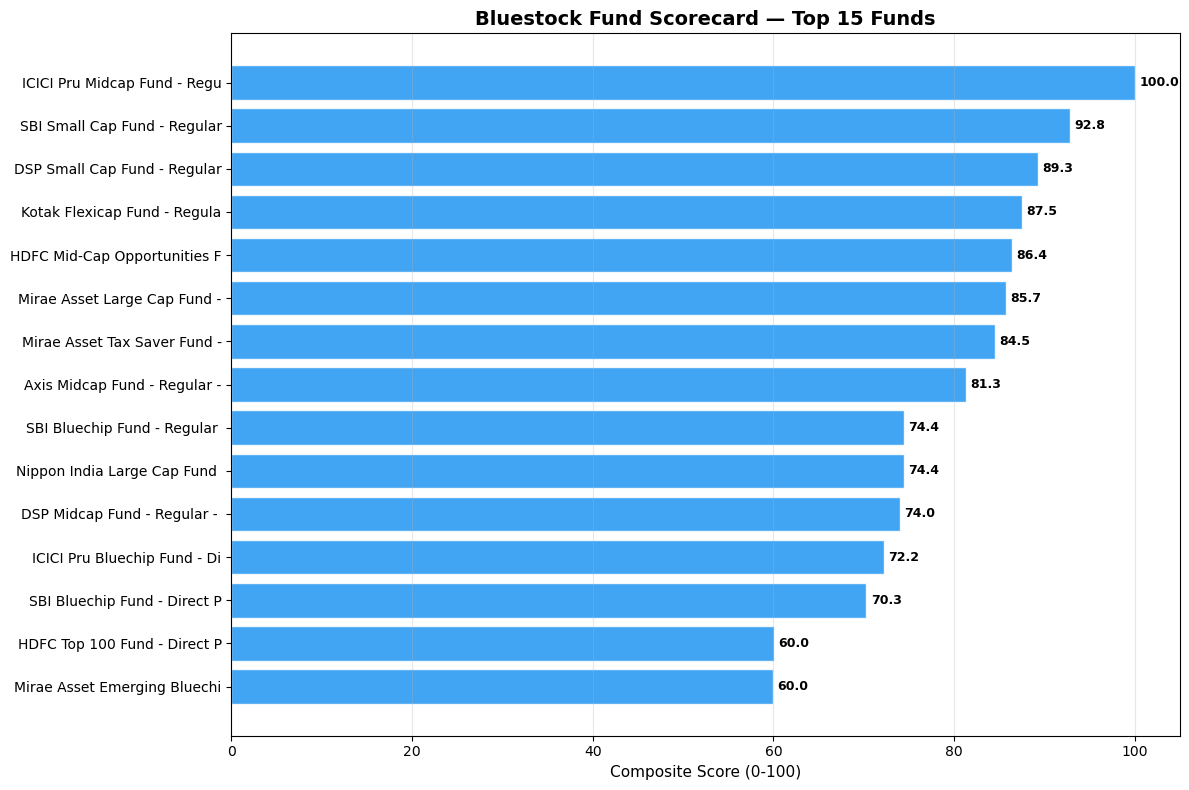

Scorecard chart saved


In [23]:
# Save scorecard to processed folder
scorecard.to_csv(PROC / "fund_scorecard.csv", index=False)
print("Scorecard saved")

# Visualize top 15 funds
top15 = scorecard.head(15)

fig, ax = plt.subplots(figsize=(12, 8))

bars = ax.barh(
    top15["scheme_name"].str[:28],
    top15["final_score"],
    color="#2196F3",
    alpha=0.85,
    edgecolor="white"
)

# Add score labels
for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.1f}",
        va="center",
        fontsize=9,
        fontweight="bold"
    )

ax.set_title("Bluestock Fund Scorecard — Top 15 Funds",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Composite Score (0-100)", fontsize=11)
ax.grid(True, alpha=0.3, axis="x")
ax.invert_yaxis()

plt.tight_layout()
plt.savefig(CHARTS / "chart16_fund_scorecard.png", dpi=150)
plt.show()
print("Scorecard chart saved")

##  Benchmark Comparison Chart:

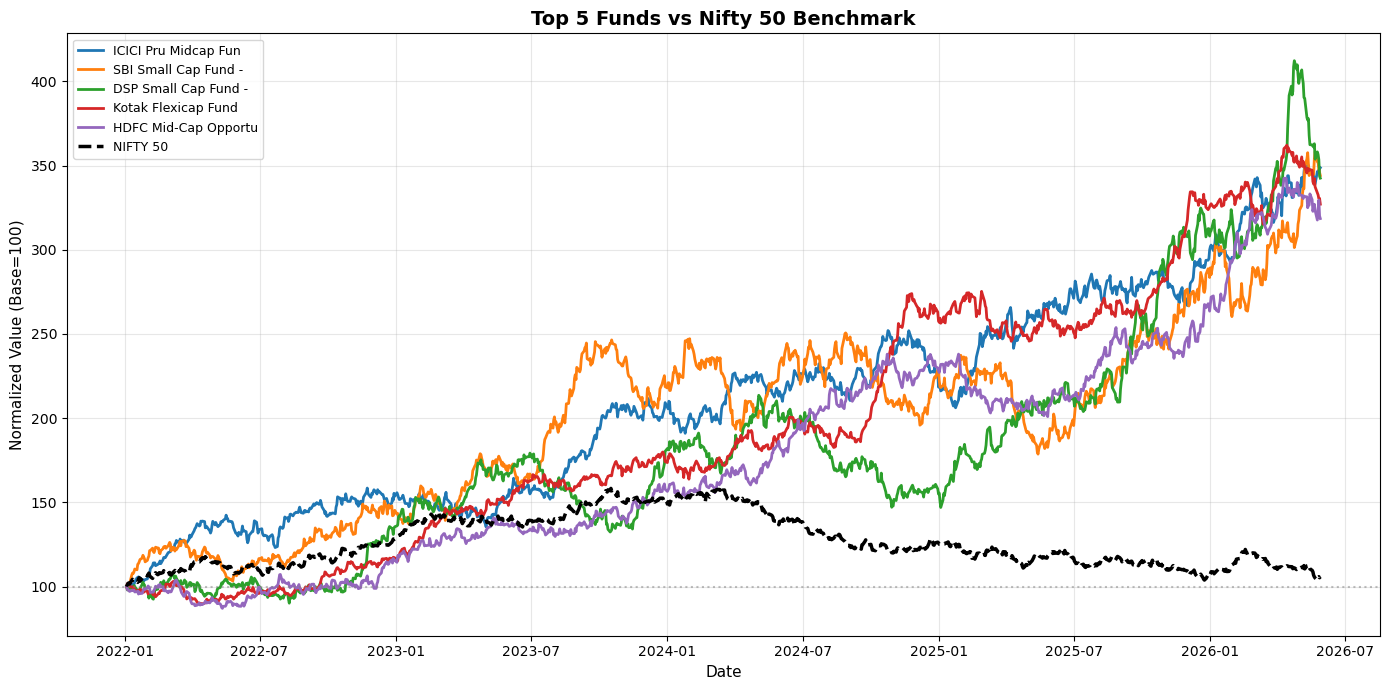

Benchmark chart saved


In [24]:
# Compare top 5 funds vs Nifty 50
# Normalize everything to start at 100

nifty = bench[bench["index_name"] == "NIFTY50"].copy()
nifty = nifty.sort_values("date")
nifty["date"] = pd.to_datetime(nifty["date"])

# Get top 5 fund codes from scorecard
top5_codes = scorecard["amfi_code"].head(5).tolist()
top5_names = scorecard.set_index("amfi_code")["scheme_name"].str[:20].to_dict()

fig, ax = plt.subplots(figsize=(14, 7))

# Plot each top 5 fund
for code in top5_codes:
    fund_nav = nav[nav["amfi_code"] == code].copy()
    fund_nav = fund_nav.sort_values("date")

    # Normalize to 100
    start_val = fund_nav["nav"].iloc[0]
    fund_nav["normalized"] = (fund_nav["nav"] / start_val) * 100

    ax.plot(
        fund_nav["date"],
        fund_nav["normalized"],
        linewidth=2,
        label=top5_names[code]
    )

# Plot Nifty 50 normalized
nifty_start = nifty["close_value"].iloc[0]
nifty["normalized"] = (nifty["close_value"] / nifty_start) * 100

ax.plot(
    nifty["date"],
    nifty["normalized"],
    color="black",
    linewidth=2.5,
    linestyle="--",
    label="NIFTY 50"
)

ax.axhline(y=100, color="gray", linestyle=":", alpha=0.5)
ax.set_title("Top 5 Funds vs Nifty 50 Benchmark",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Date", fontsize=11)
ax.set_ylabel("Normalized Value (Base=100)", fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(CHARTS / "chart17_benchmark_comparison.png", dpi=150)
plt.show()
print("Benchmark chart saved")

In [ ]:
# Business insight for your report: All top 5 funds outperformed the Nifty 
# 50 benchmark over the 4-year period. This means active fund management added 
# genuine value — investors who chose these funds earned more than they would
# have by simply buying a Nifty 50 index fund. This justifies the higher expense 
# ratio of actively managed funds.